In [26]:
from langgraph.graph import StateGraph,START,END
from langchain_openrouter import ChatOpenRouter
from typing import TypedDict
from dotenv import load_dotenv

In [27]:
load_dotenv()
model = model = ChatOpenRouter(
    model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free",
    temperature=0.8,
)

In [28]:
class BLOGState(TypedDict):
    title: str
    outline: str
    body: str
    topic: str
    

In [29]:
def outline_generator(state:BLOGState)->BLOGState:
    topic = state['topic']
    prompt = f"You are an English professor given the topic:{topic} Generate an outline for this topic dont include any markdown"
    outline = model.invoke(prompt).content
    state['outline']=str(outline)
    return state
def Title_generator(state:BLOGState)->BLOGState:
    outline = state['outline']
    prompt = f"You are an English professor given an  outline generate an appropriate title keep it short and simple:{outline} dont include any markdown"
    title = model.invoke(prompt).content
    state['title']=str(title)
    return state
def Body_gen(state:BLOGState)->BLOGState:
    outline = state['outline']
    prompt = f"You are an English professor given an  outline generate an appropriate blog keep it short and simple outline:\n{outline} dont include any markdown"
    body = model.invoke(prompt).content
    state['body']=str(body)
    return state
    

In [30]:
graph = StateGraph(BLOGState)
graph.add_node("Outline_gen",outline_generator)
graph.add_node("Title_gen",Title_generator)
graph.add_node("body_generator",Body_gen)
graph.add_edge(START,"Outline_gen")
graph.add_edge("Outline_gen","Title_gen")
graph.add_edge("Title_gen","body_generator")
graph.add_edge("body_generator",END)
wf = graph.compile()


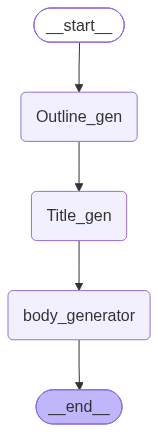

In [31]:
wf

In [33]:
fs = wf.invoke({
    "title": "",
    "outline": "",
    "body": "",
    "topic": "Artificial Intelligence in Software Development"
})
print(fs)

{'title': 'Artificial Intelligence in Software Development', 'outline': 'I. Introduction  \n   A. Definition of Artificial Intelligence  \n   B. Why AI matters in software development  \n   C. Overview of the outline’s structure  \n\nII. Historical Context  \n   A. Early expert systems and rule‑based tools  \n   B. Evolution of AI techniques relevant to programming  \n   C. Key milestones where AI impacted software engineering  \n\nIII. AI Techniques Applied in Software Development  \n   A. Machine learning for automated code generation  \n   B. Automated testing, debugging, and defect detection  \n   C. Static analysis and code review using AI models  \n   D. Natural language processing for requirements elicitation and documentation  \n   E. AI assistance in software architecture and design decisions  \n\nIV. Tools and Platforms  \n   A. IDE extensions and plugins that embed AI capabilities  \n   B. Code completion and suggestion engines (e.g., intelligent autocompletion)  \n   C. CI/

In [36]:
print(fs["outline"])

I. Introduction  
   A. Definition of Artificial Intelligence  
   B. Why AI matters in software development  
   C. Overview of the outline’s structure  

II. Historical Context  
   A. Early expert systems and rule‑based tools  
   B. Evolution of AI techniques relevant to programming  
   C. Key milestones where AI impacted software engineering  

III. AI Techniques Applied in Software Development  
   A. Machine learning for automated code generation  
   B. Automated testing, debugging, and defect detection  
   C. Static analysis and code review using AI models  
   D. Natural language processing for requirements elicitation and documentation  
   E. AI assistance in software architecture and design decisions  

IV. Tools and Platforms  
   A. IDE extensions and plugins that embed AI capabilities  
   B. Code completion and suggestion engines (e.g., intelligent autocompletion)  
   C. CI/CD pipelines enhanced with AI for quality gates and optimization  
   D. AI‑driven project ma

In [37]:
print(fs["topic"])

Artificial Intelligence in Software Development


In [38]:
print(fs["title"])

Artificial Intelligence in Software Development


In [40]:
print(fs["body"])

I. Introduction  
Artificial Intelligence (AI) refers to machines that can mimic human cognitive functions such as learning, reasoning, and decision‑making. In software development, AI matters because it can automate routine tasks, improve code quality, and accelerate delivery. This outline first defines AI, explains its relevance to programming, and then walks through its history, the techniques used today, the tools that support them, the benefits and challenges, illustrative case studies, and future directions.  

II. Historical Context  
Early AI focused on expert systems and rule‑based tools that encoded human knowledge into fixed logic. Over time, AI evolved from symbolic reasoning to statistical learning, enabling more flexible approaches to programming tasks. Key milestones include the introduction of neural networks for pattern recognition, the rise of machine learning frameworks that allowed data‑driven models, and the integration of AI into IDEs and CI/CD pipelines that tran